

先运行所有单元。计算使用同目录下的 `run_reproduction.py` 和作者源码适配副本。每一步的来源、原版差异及下一步见 [[README]]。本 notebook 只做资源估计，不模拟量子线路。

## 1. 这次用的参数

| 参数 | 值 | 作用 |
|---|---:|---|
| 8-SAT 子句密度 $r$ | 176 | 决定 phaser 的子句总量 |
| 物理错误率 $p_{ph}$ | $10^{-3}$ | 表面码码距输入 |
| 表面码阈值 $p_{th}$ | $10^{-2}$ | 表面码码距输入 |
| 电路目标保真度 $F$ | 0.99 | 可容忍失败概率 0.01 |
| 逻辑周期 | $d\times1$ 微秒 | 将逻辑深度换成实际时间 |

作者的经典运行时间分布拟合参数读取自 `optimized_parameters.txt` 第 3 行（Rand-9），与 Figure 3B/3D 原 notebook 一致。

In [1]:
# 看作者 Rand-9 拟合参数；这里的 lambda 是移位指数分布的速率，不是 QAOA 参数。
from run_reproduction import LAMBDA, SHIFT, CASES, first_crossover
print(f"lambda = {LAMBDA:.9g}, shift = {SHIFT:.9g} ns")
for case in CASES:
    print(case["name"], "目标加速 =", case["speedup"])

lambda = 0.000979024368, shift = 6.77496404 ns
quadratic 目标加速 = 2
cubic 目标加速 = 3
quartic 目标加速 = 4


## 2. 找 Figure 3A 的交叉点

作者函数先依据加速目标决定 QAOA 深度 $p$，随后计算经典时间 $T_c$、量子时间 $T_q$。我们逐个试整数问题规模 $n$，找首次满足 $T_c\ge T_q$ 的位置。

In [2]:
# 真正搜索交叉点；论文中的 n 只用于之后核对，不参加搜索。
rows = [first_crossover(case) for case in CASES]
for case, row in zip(CASES, rows):
    print(f"{case['name']:9s}  n={row['n']}  p={row['p']}  "
          f"Tq={__import__('math').exp(row['log_Tq'])/3600:.3f} 小时  "
          f"论文 n={case['n_paper']}")

quadratic  n=242  p=71  Tq=25500.940 小时  论文 n=242
cubic      n=191  p=253  Tq=64.550 小时  论文 n=191
quartic    n=179  p=623  Tq=14.990 小时  论文 n=179


## 3. 看总门数 $G$ 和表面码码距 $d$

作者先算单次成功概率 $P=2^{-0.69p^{-0.32}n}$，再估算幅度放大次数 $R=\lfloor\pi/(4\sqrt P)\rfloor$。旋转门数量 $N_{rot}=2pn(176+1)R$，总非 Clifford 门数上界 $G=N_{rot}(7+N_T)$。

表面码使用 $q=p_{ph}/p_{th}=0.1$。为了让总失败概率不超过 0.01，检查 $Gq^{d/2}\le0.01$。注意：这里的 $G$ 是整个算法的门数，不是 TACU 数量。

In [3]:
# 联合界：每个门出错的保守上界约为 q^(d/2)，G 个门相加。
for case, row in zip(CASES, rows):
    G, d = row["G"], row["d"]
    bound = G * 0.1 ** (d / 2)
    print(f"{case['name']:9s}  G={G:.4g}  d={d}  "
          f"失败概率上界={bound:.4g}  论文 d={case['paper']['d']}")
    assert bound <= 0.01

quadratic  G=4.19e+14  d=34  失败概率上界=0.00419  论文 d=35
cubic      G=9.586e+11  d=28  失败概率上界=0.009586  论文 d=29
quartic    G=2.106e+11  d=27  失败概率上界=0.006661  论文 d=28


## 4. 生成 Figure 3A 和 Table III 对照

运行下面的脚本会保存 PNG、CSV 和 Markdown 对照表。图片是按照 Figure 3A 的关键数字重新作图，不复制原图版式。对照表**保留**作者源码与论文的 $d$、$N_T$ 和物理量子比特差异。

In [4]:
# 生成全部输出文件；运行结果在 results/ 文件夹。
from run_reproduction import main
main()

quadratic: n=242, p=71, d=34, G=4.19e+14, Tq=25500.940 h
cubic    : n=191, p=253, d=28, G=9.59e+11, Tq=64.550 h
quartic  : n=179, p=623, d=27, G=2.11e+11, Tq=14.990 h
结果已保存到：D:\桌面\QAOA 8SAT 作者源码简单复现\results


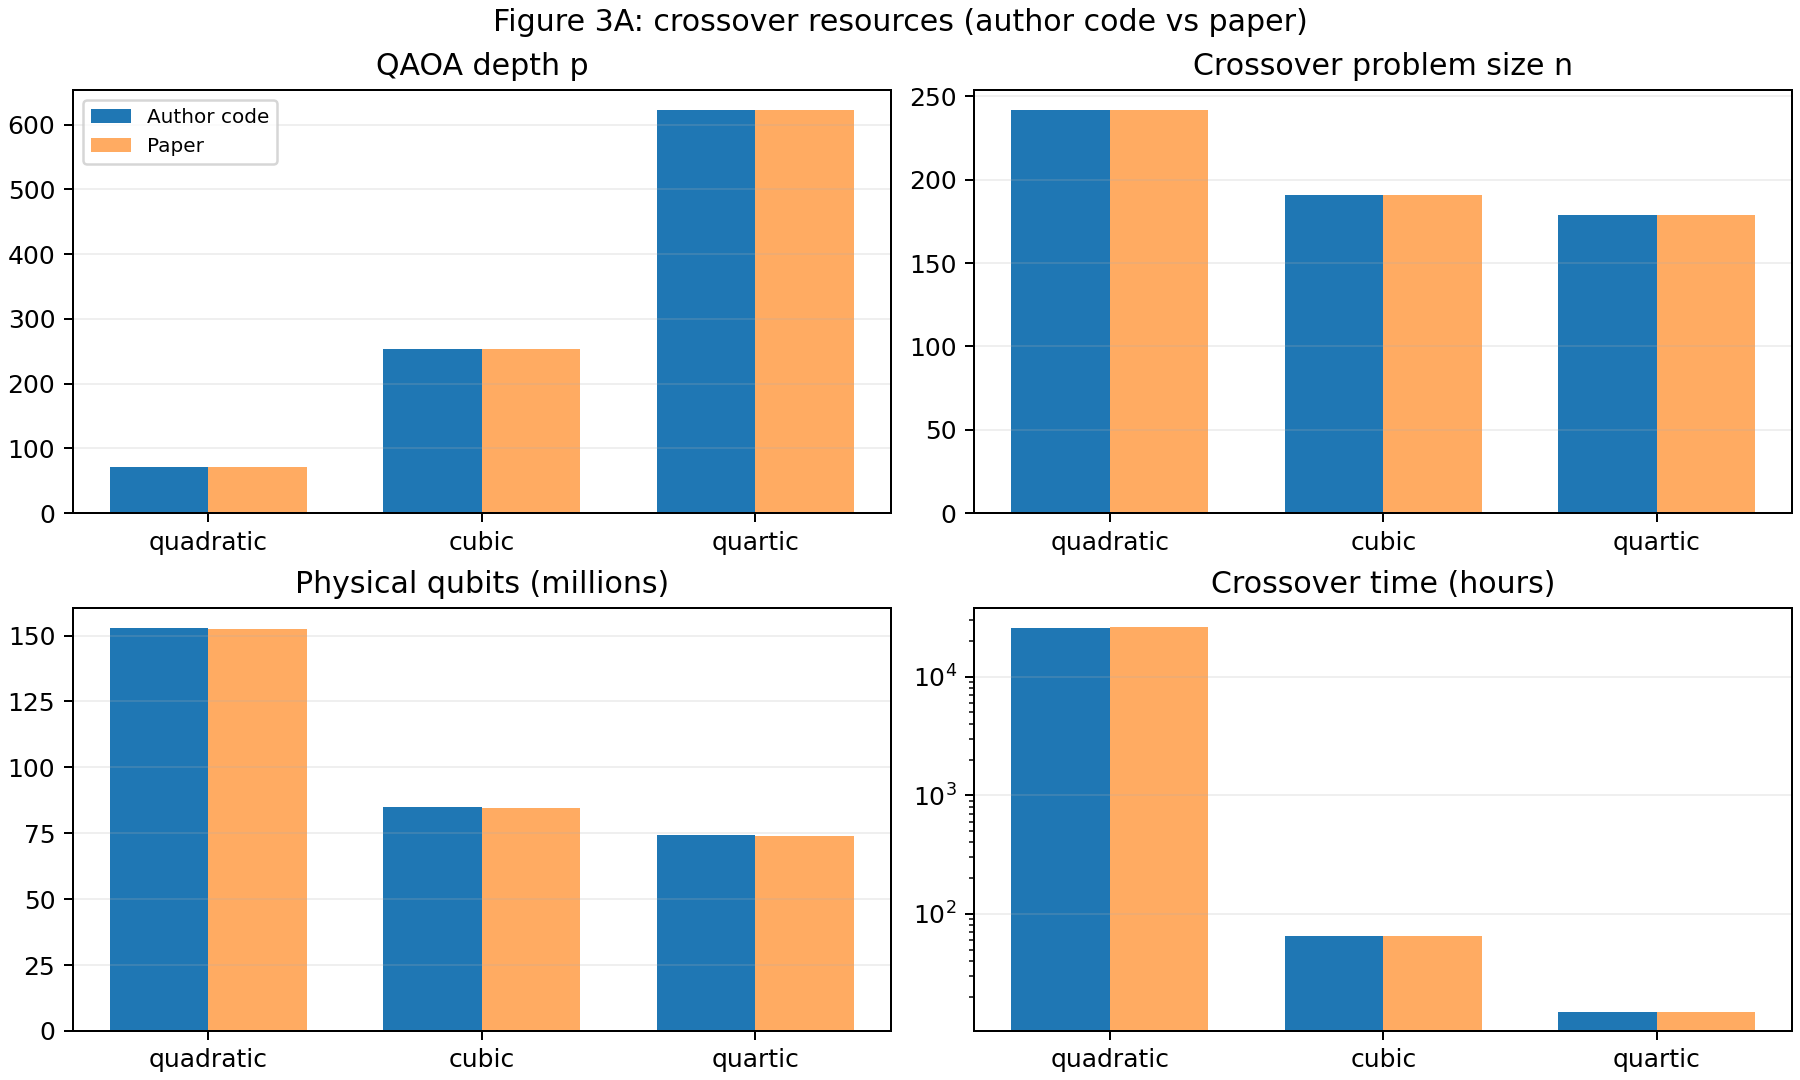

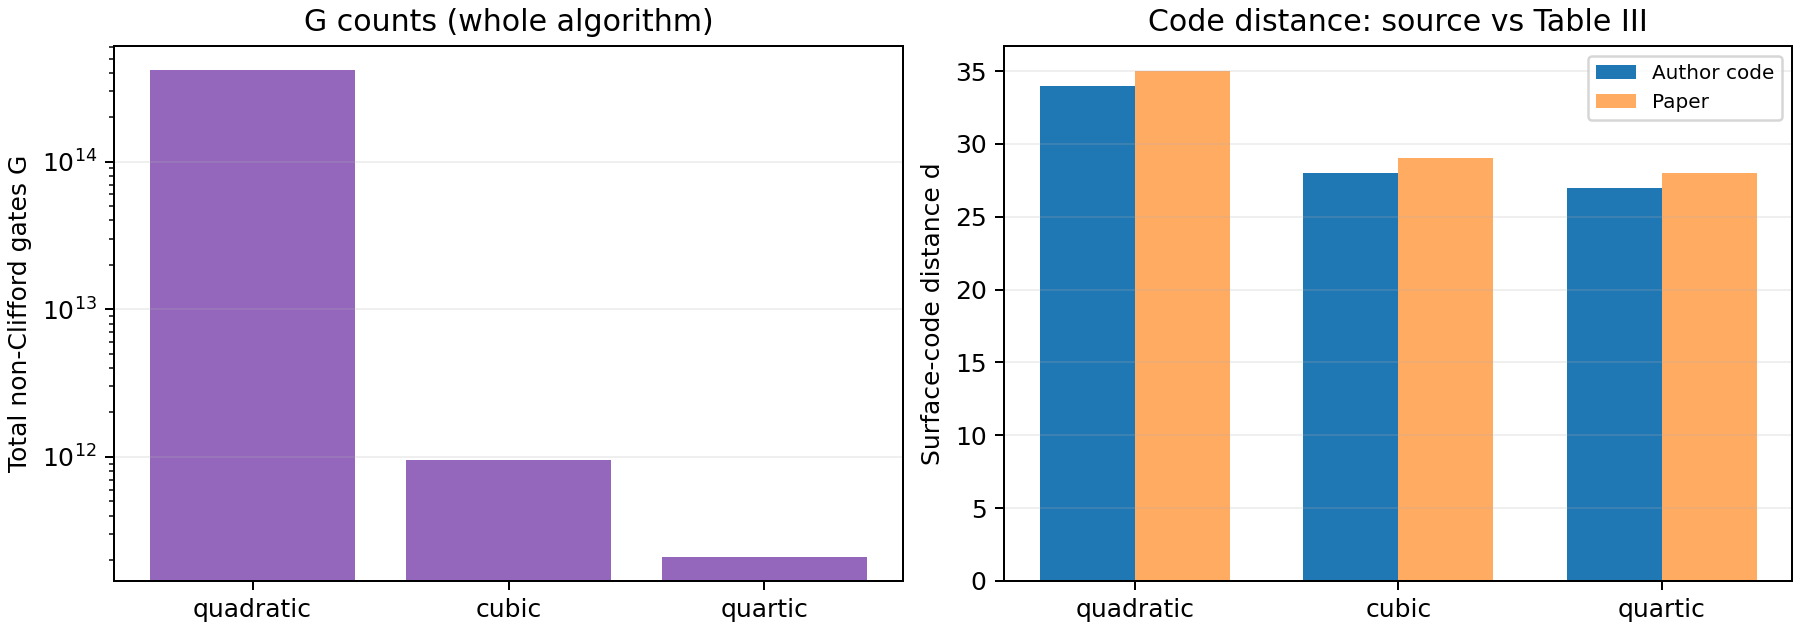

In [5]:
# 在 notebook 里直接显示两张核心图：Figure 3A 和 G/表面码。
from IPython.display import Image, display
from pathlib import Path
display(Image(filename=str(Path("results/figure_3A_reproduction.png"))))
display(Image(filename=str(Path("results/G_and_surface_code.png"))))

In [6]:
# 在 notebook 里直接显示 Table III 的 Markdown 对照。
from IPython.display import Markdown
print(Path("results/table_III_comparison.md").read_text(encoding="utf-8"))

# Table III：作者源码输出与论文对照

| 指标 | quadratic：源码 / 论文 | cubic：源码 / 论文 | quartic：源码 / 论文 |
|---|---:|---:|---:|
| n | 242 / 242 | 191 / 191 | 179 / 179 |
| p | 71 / 71 | 253 / 253 | 623 / 623 |
| d | 34 / 35 | 28 / 29 | 27 / 28 |
| G / 10^12 | 419 / 419 | 0.9586 / 0.96 | 0.2106 / 0.21 |
| depth / 10^8 | 6750 / 6750 | 20.75 / 20.76 | 4.997 / 5 |
| qubits / 10^6 | 153 / 152.4 | 84.82 / 84.43 | 74.27 / 73.91 |
| jobs | 840 / 840 | 592 / 592 | 540 / 540 |
| ancilla | 43680 / 43680 | 30784 / 30784 | 28080 / 28080 |
| N_T | 26 / 27 | 23 / 24 | 22 / 23 |
| rotation error | 1.756e-09 / 1.76e-09 | 6.654e-08 / 6.65e-08 | 1.414e-07 / 1.41e-07 |
| T infidelity | 1e-17 / 1e-17 | 1.436e-14 / 1.44e-14 | 6.485e-14 / 6.48e-14 |
| decoder | 52322 / 52320 | 36895 / 36900 | 33659 / 33660 |
| cores | 71 / 71 | 50 / 50 | 46 / 46 |
| Tq / h | 2.55e+04 / 2.628e+04 | 64.55 / 64.57 | 14.99 / 14.99 |

## 表面码与 G 的计算

作者源码取 $p_{ph}=10^{-3}$、$p_{th}=10^{-2}$、目标电路保真度 $F=0.99$。
总非 Clifford 门数：$G=N_{rot}(7+N_T)$，其中 $N_{rot

## 5. 回到论文核对

- [ ] Fig. 3A：三种加速对应的 $n$、$p$、物理量子比特和时间是否同量级？
- [ ] Eq. (21)–(23)：把 $F=0.99$ 与失败概率 $0.01$ 区分清楚了吗？
- [ ] Table III：$G$、码距、逻辑深度、工厂数、辅助量子比特逐列对照了吗？
- [ ] 留意源码的 `qaa_fac=4` 已放在 $T_q$，无需对运行时间再次乘 4。